In [2]:
# Basic imports and setup
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 200

# Import the new data loader and plotting functions
from analyze_modules import ChelioRun, plot_all_iteration_profiles, plot_profile, plot_rcb_height

# from ../chelio_sim import mixfile_utils.py
import sys
sys.path.append('../chelio_sim')
from mixfile_utils import p_sat

In [13]:
# Load a single simulation run
# All data loading, parsing, and iteration handling is done by ChelioRun.
output_folder = "../output/CIA_comparison_HELIOS/"
run_name = "CIA_CO2-CH4_2020_Tint=200K_Psurf=100bar"
#run_name = "Earth_Tint=150K_Psurf=10bar_aH=1.0_aC=0.1_aO=0.01_aN=1.0"
#run_name = "Earth_P0=1e8_Tint=50_CplusO=1e-2_CtoO=0.59"
#run_name = "test"

# Load all iterations to see the evolution
run = ChelioRun(output_folder, run_name, load_mode='all')
run.read_data()

# Basic run info is now stored as attributes
print(f"Loaded {run.num_iterations_read} iterations for run: {run.run_name}")
print(f"Final convergence status: {run.final_convergence_status}")
print(f"Species found: {run.n_mol} molecules, {run.n_dust} condensates")

Loaded 12 iterations for run: CIA_CO2-CH4_2020_Tint=200K_Psurf=100bar
Final convergence status: False
Species found: 6 molecules, 0 condensates


In [14]:
def set_white(ax):
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    ax.tick_params(axis='x', colors='white', which='both')  # Set color for both major and minor ticks
    ax.tick_params(axis='y', colors='white', which='both')  # Set color for both major and minor ticks

def increase_size(ax, linewidth=3, fontsize=14, legendcols=1, legendloc='best'):
    for l in ax.lines:
        l.set_linewidth(linewidth)
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(linewidth)
    ax.xaxis.set_tick_params(width=linewidth)
    ax.yaxis.set_tick_params(width=linewidth)
    ax.xaxis.label.set_size(fontsize)
    ax.yaxis.label.set_size(fontsize)
    ax.xaxis.set_tick_params(labelsize=fontsize)
    ax.yaxis.set_tick_params(labelsize=fontsize)
    if legendloc != 'no':
        ax.legend(fontsize=fontsize, ncols=legendcols, loc=legendloc)
    

(12, 85) (12, 85)
[100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.]
[500.      80.6319  83.4038  81.3053  83.1235  82.0421  82.8513  82.3818
  82.6994  82.5189  82.636   82.5643]
[500.    591.309 635.428 635.989 635.93  636.038 636.011 636.064 636.041
 636.063 636.059 636.065]
0.0060000000000854925


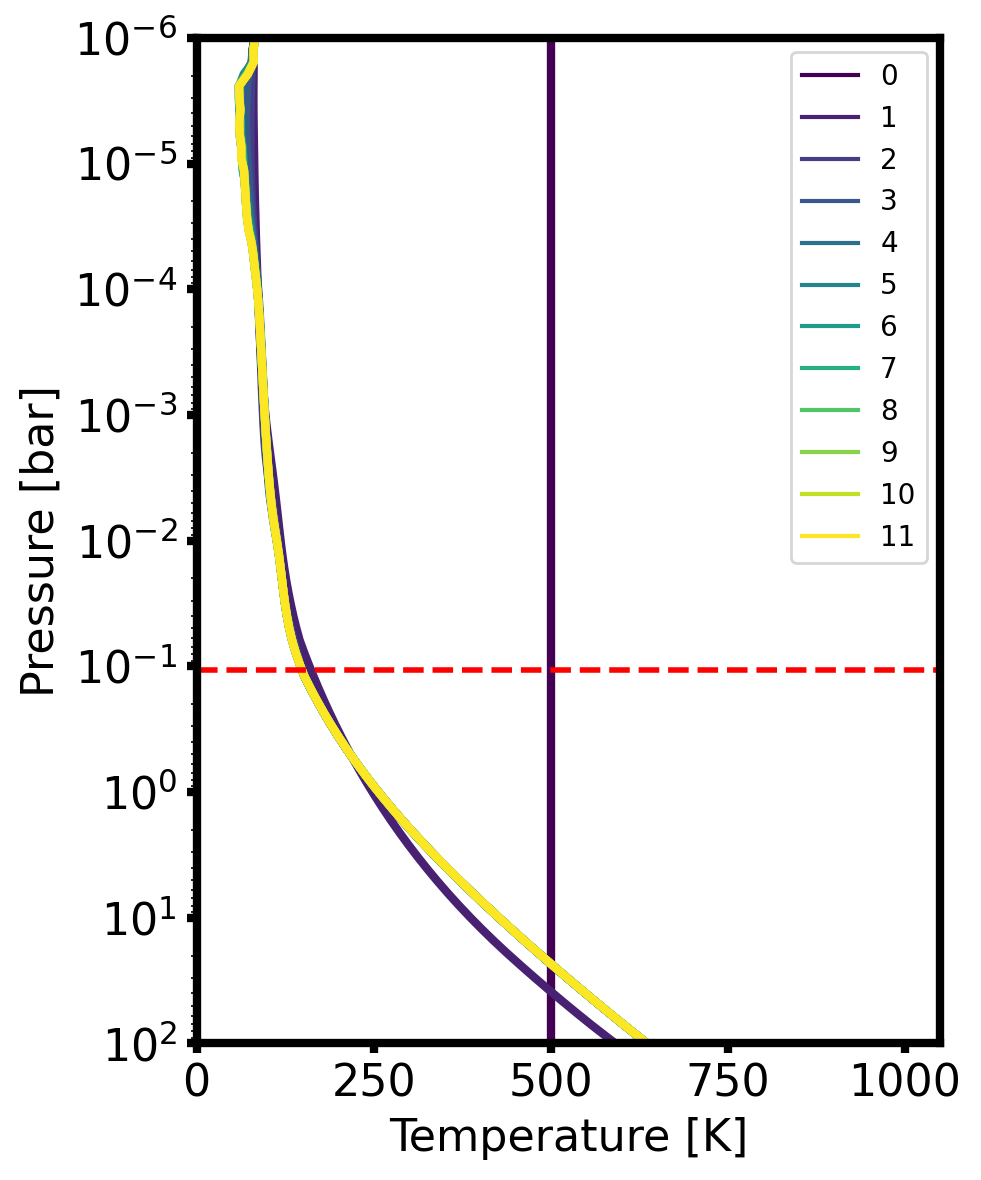

In [15]:
# Plot the T-P profile evolution across all iterations
fig, ax = plt.subplots(1, 1, figsize=(5, 6))

print(run.pressures_bar.shape, run.temperatures_K.shape)
print(run.pressures_bar[:,0])
print(run.temperatures_K[:,-1])
print(run.temperatures_K[:,0])

print((np.abs(run.temperatures_K[-2,0] - run.temperatures_K[-1,0])))#/run.temperatures_K[-1,:]).max())

# The new plotting utility handles the looping and coloring
plot_all_iteration_profiles(
    run, 
    'temperature', 
    y_axis='pressure', 
    ax=ax,
    cmap_name='viridis', #'Wistia'
    legend = True
)

ax.set_xlim(0, 1050)

# Add the RCB line using the dedicated function
plot_rcb_height(run, ax=ax, color='red', linestyle='--', linewidth=2, label='RCB')

# set to max and min pressure
ax.set_ylim(np.nanmax(run.pressures_bar), np.nanmin(run.pressures_bar))
#ax.set_ylim(np.nanmax(run.pressures_bar), 1e0)
ax.set_title(run.run_name.replace("_", ", "))

# turn on preferred options
#set_white(ax)
increase_size(ax, linewidth=3, fontsize=16, legendcols=2, legendloc='no')
ax.set_title('')
plt.tight_layout()
#plt.savefig(f"images/JulyPoster/TPevolution_{run_name}.svg", format="svg", transparent=True)

# insert the saturation vapor pressure of choice for reference
#T_sample = np.linspace(0, 650, 100)
#p_sat_sample = p_sat(T_sample, 'CO2')*1e-6 # convert from dyn/cm^2 to bar
#ax.plot(T_sample, p_sat_sample, color='black', linestyle='--', linewidth=1, label='CO2 saturation pressure', zorder=0)

if False:
    t_min = float(np.nanmin(run.temperatures_K[-1,:])) * 0.9
    t_max = float(np.nanmax(run.temperatures_K[-1,:])) * 1.1
    if not np.isfinite(t_min) or not np.isfinite(t_max):
        raise ValueError("Temperature profile contains non-finite values")
    if t_max < t_min:
        t_min, t_max = t_max, t_min
    n_intervals = int(np.ceil(max(t_max - t_min, 0.0) / 20))
    n_intervals = max(n_intervals, 1)
    t_grid = np.linspace(t_min, t_max, n_intervals + 1)
    plt.vlines(t_grid, np.nanmin(run.pressures_bar), np.nanmax(run.pressures_bar), colors='gray', linewidth=0.5)
    plt.hlines(run.pressures_bar[-1,:], t_min, t_max, colors='gray', linewidth=0.5)

plt.show()

log


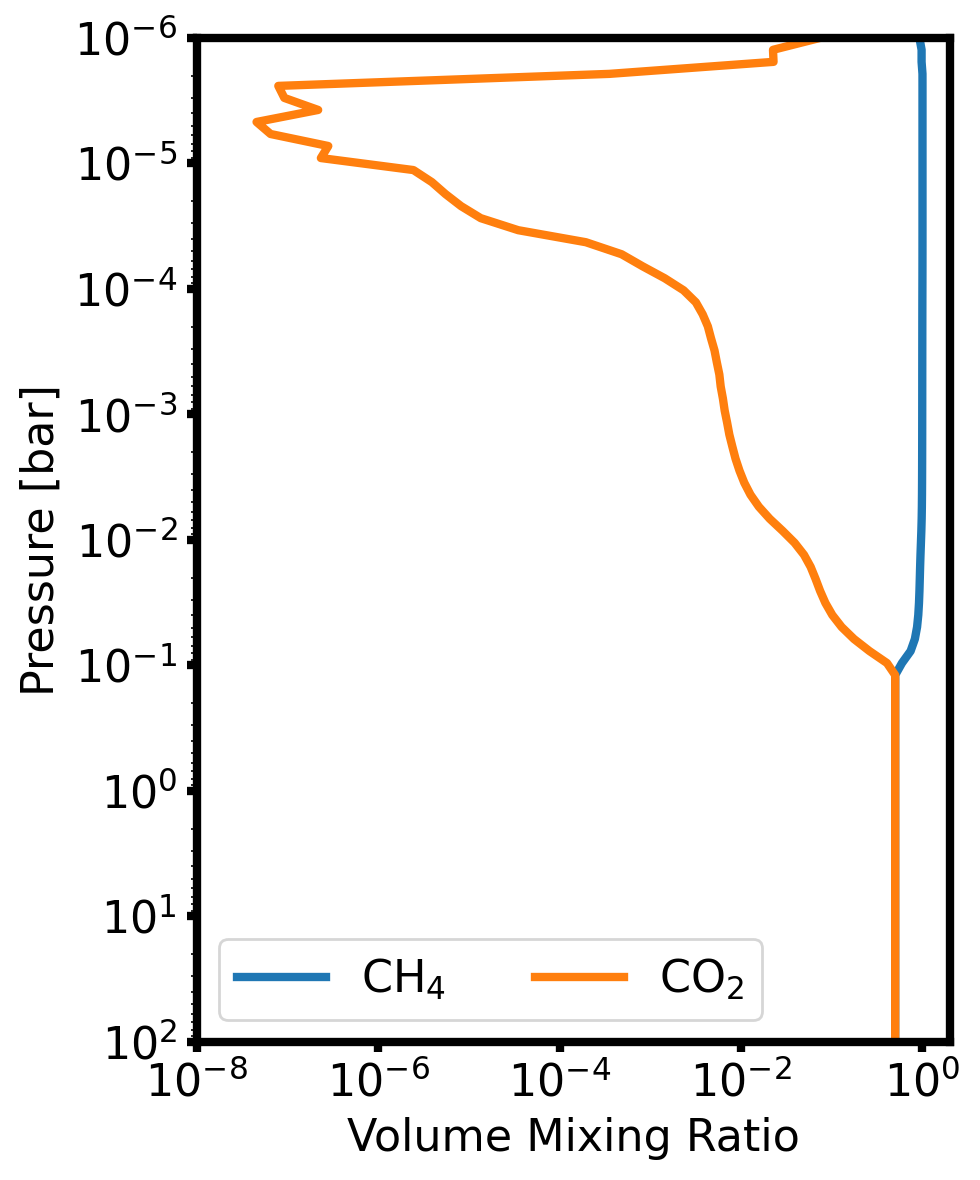

: 

In [ ]:
# Plot molecular mixing ratios for the final converged step
i = -1

# Find 
threshold = 1e-8

if threshold is not None:
    mask = run.mols_vmr[i] > threshold
    mask = np.any(mask, axis=0)
else:
    target_molecules = ['H2', 'H2O', 'CO2', 'CO', 'CH4', 'C2H2', 'C2H4']
    mask = np.isin(run.mol_names, target_molecules)

target_molecules = np.array(run.mol_names)[mask]

fig, ax = plt.subplots(1, 1, figsize=(5, 6))

# plot_profile can now take a list of molecules to plot
plot_profile(
    run, 
    param_key=target_molecules, 
    y_axis='pressure', 
    log_x=True, 
    ax=ax,
    iteration_index=i,
    mol_type='mol'
)

print(ax.get_xscale())
ax.set_xscale('log')
ax.set_xlim(1e-8, 2)

#ax.set_xlim(1e-12, 2e0)
ax.set_ylim(np.nanmax(run.pressures_bar), np.nanmin(run.pressures_bar))
ax.set_xlabel("Volume Mixing Ratio")
ax.set_title(run.run_name.replace("_", ", "))

# turn on preferred options
#set_white(ax)
increase_size(ax, linewidth=3, fontsize=16, legendcols=2)
ax.set_title('', fontsize=16)
#ax.set_ylabel('')
plt.tight_layout()
#plt.savefig(f"images/JulyPoster/FinalChem_{run_name}.svg", format="svg", transparent=True)

plt.show()

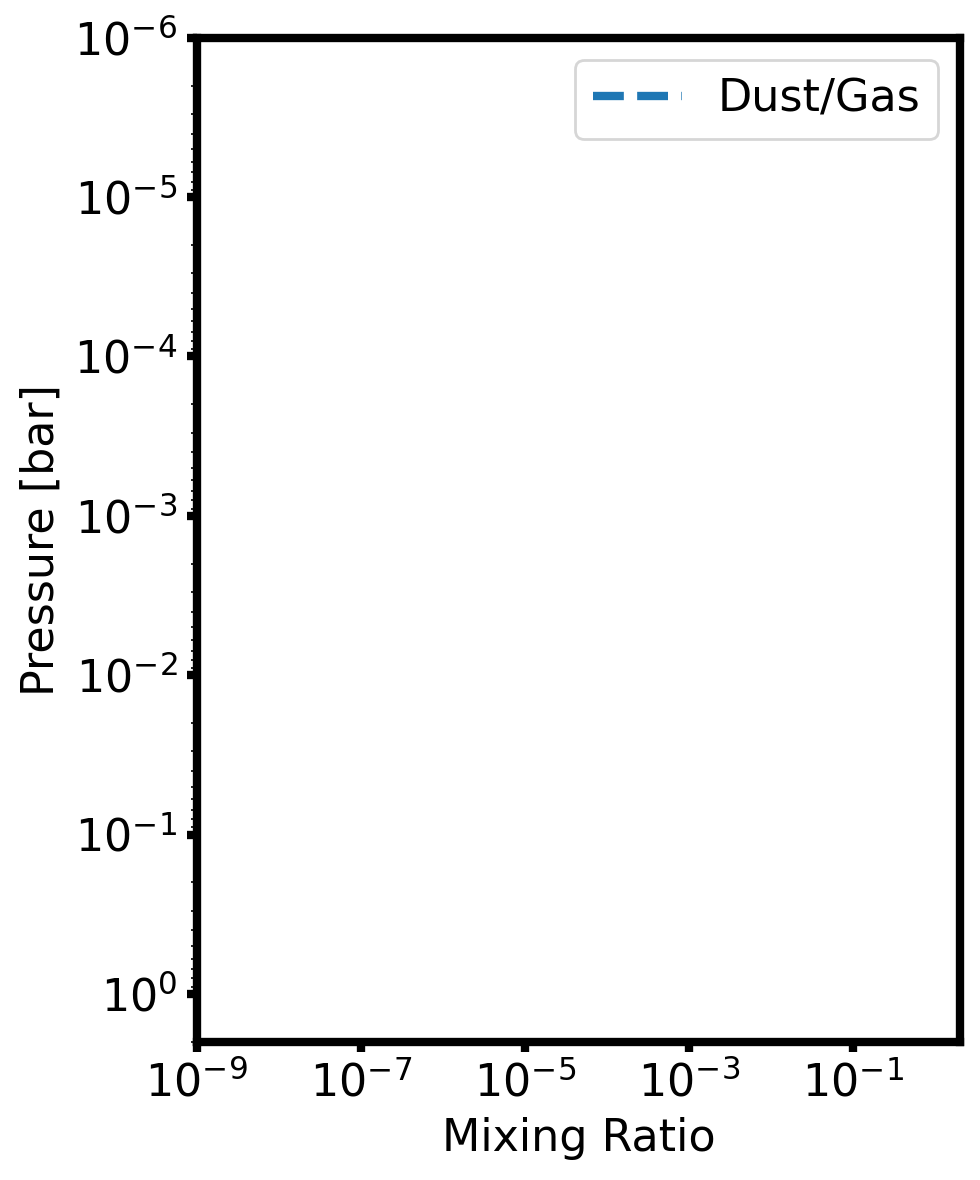

In [6]:
# plot the dust "mixing ratios"
i = -1

threshold = 1e-12

if threshold is not None:
    mask = run.dusts_vmr[i] > threshold
    mask = np.any(mask, axis=0)
else:
    target_molecules = run.dust_names #['H2', 'H2O', 'H2O[l]', 'CO2', 'CO', 'CH4', 'NH3']
    mask = np.isin(run.dust_names, target_molecules)
    #sort = np.argsort(mols[i][:,mask].max(axis=0))[::-1]

target_molecules = np.array(run.dust_names)[mask]

# Plot dust mixing ratios for the final converged step
fig, ax = plt.subplots(1, 1, figsize=(5, 6))

# We can directly use the list of dust names from the run object
plot_profile(
    run, 
    param_key=target_molecules,
    y_axis='pressure', 
    log_x=True, 
    ax=ax,
    iteration_index=i,
    mol_type='dust'
)

plot_profile(
    run, 
    param_key='dust_to_gas_mr',
    y_axis='pressure', 
    log_x=True, 
    ax=ax,
    iteration_index=i,
    label='Dust/Gas',
    linestyle='--'
)

ax.legend() # not called if plotting only one parameter

ax.set_xlim(1e-9, 2e0)
ax.set_ylim(np.nanmax(run.pressures_bar), np.nanmin(run.pressures_bar))
ax.set_xlabel("Mixing Ratio")
ax.set_title(run.run_name.replace("_", ", "))

# turn on preferred options
#set_white(ax)
increase_size(ax, linewidth=3, fontsize=16, legendcols=1)
ax.set_title('')
plt.tight_layout()

plt.show()

/tmp/ipykernel_1474/4182182402.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=fontsize, ncols=legendcols, loc=legendloc)


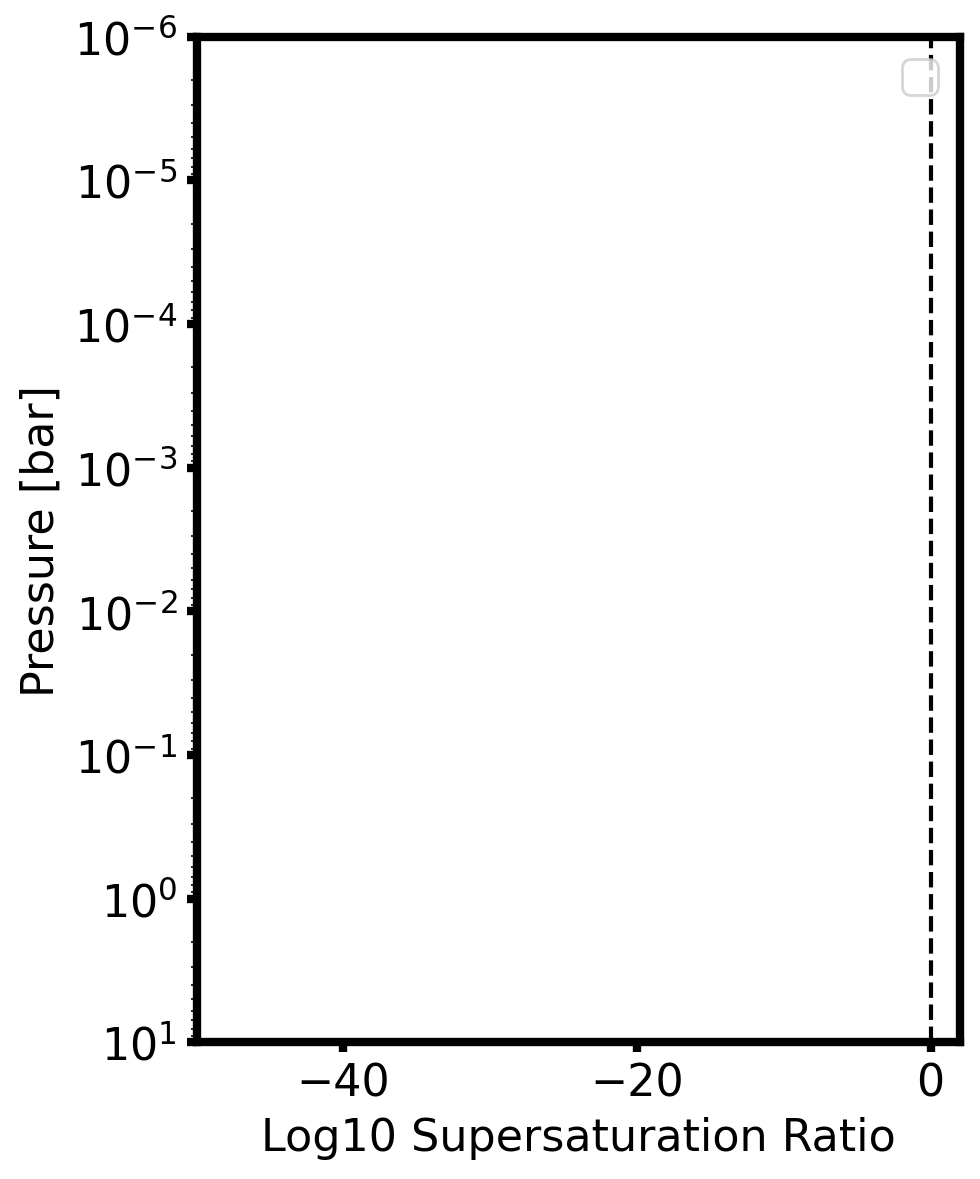

In [10]:
# plot supersaturation ratios of dust species
i = -1

threshold = None

if threshold is not None:
    mask = run.supersats[i] > threshold
    mask = np.any(mask, axis=0)
else:
    target_molecules = run.dust_names #['H2', 'H2O', 'H2O[l]', 'CO2', 'CO', 'CH4', 'NH3']
    mask = np.isin(run.dust_names, target_molecules)
    #sort = np.argsort(mols[i][:,mask].max(axis=0))[::-1]

target_molecules = np.array(run.dust_names)[mask]

# Plot supersaturation ratios for the final converged step
fig, ax = plt.subplots(1, 1, figsize=(5, 6))

# Plot reference line at 0 (1e0)
ax.vlines(0, run.pressures_bar.max(), run.pressures_bar.min(), linestyle='dashed', color='black')

# We can directly use the list of dust names from the run object
plot_profile(
    run, 
    param_key=target_molecules,
    y_axis='pressure', 
    log_x=False, 
    ax=ax,
    iteration_index=i,
    mol_type='supersat'
)

ax.set_xlim(-50, 2)
ax.set_ylim(run.pressures_bar.max(), run.pressures_bar.min())
ax.set_xlabel("Log10 Supersaturation Ratio")
ax.set_title(run.run_name.replace("_", ", "))

# turn on preferred options
#set_white(ax)
increase_size(ax, linewidth=3, fontsize=16, legendcols=1)
ax.set_title('')
plt.tight_layout()

plt.show()

/tmp/ipykernel_1474/4182182402.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=fontsize, ncols=legendcols, loc=legendloc)


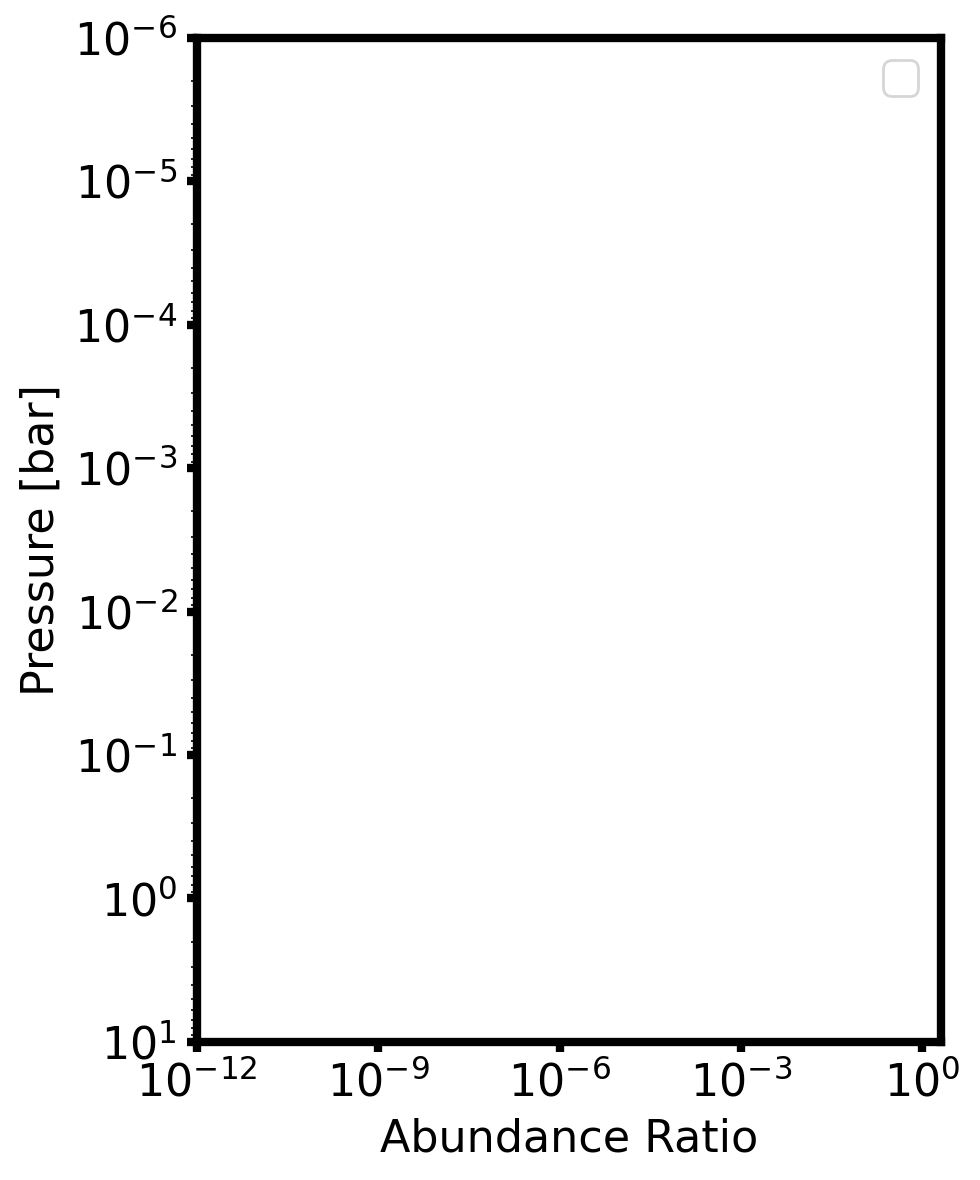

In [11]:
# plot abundance ratios of atoms and dust/gas ratio
i = -1

fig, ax = plt.subplots(1, 1, figsize=(5, 6))

# We can directly use the list of dust names from the run object
plot_profile(
    run, 
    param_key=run.atom_names[1:],
    y_axis='pressure', 
    log_x=True, 
    ax=ax,
    iteration_index=i,
    mol_type='eps'
)

ax.set_xlim(1e-12, 2e0)
ax.set_ylim(run.pressures_bar.max(), run.pressures_bar.min())
ax.set_xlabel("Abundance Ratio")
ax.set_title(run.run_name.replace("_", ", "))

# turn on preferred options
#set_white(ax)
increase_size(ax, linewidth=3, fontsize=16, legendcols=1)
ax.set_title('')
plt.tight_layout()

plt.show()

In [10]:
# read in contribution function
# (not in-built)
# header: bin     cent_lambda[um]   low_int_lambda[um]   delta_lambda[um]   contr_func_lay[0]   contr_func_lay[1]   ...
contribution_file = output_folder + run_name + f"/{run_name}_contribution.dat"
contribution_data = np.loadtxt(contribution_file, skiprows=2)

FileNotFoundError: ../output/N2dom_fast/Earth_Tint=150K_Psurf=100bar_aH=1.0_aC=0.5_aO=0.01_aN=1.0/Earth_Tint=150K_Psurf=100bar_aH=1.0_aC=0.5_aO=0.01_aN=1.0_contribution.dat not found.

NameError: name 'contribution_data' is not defined

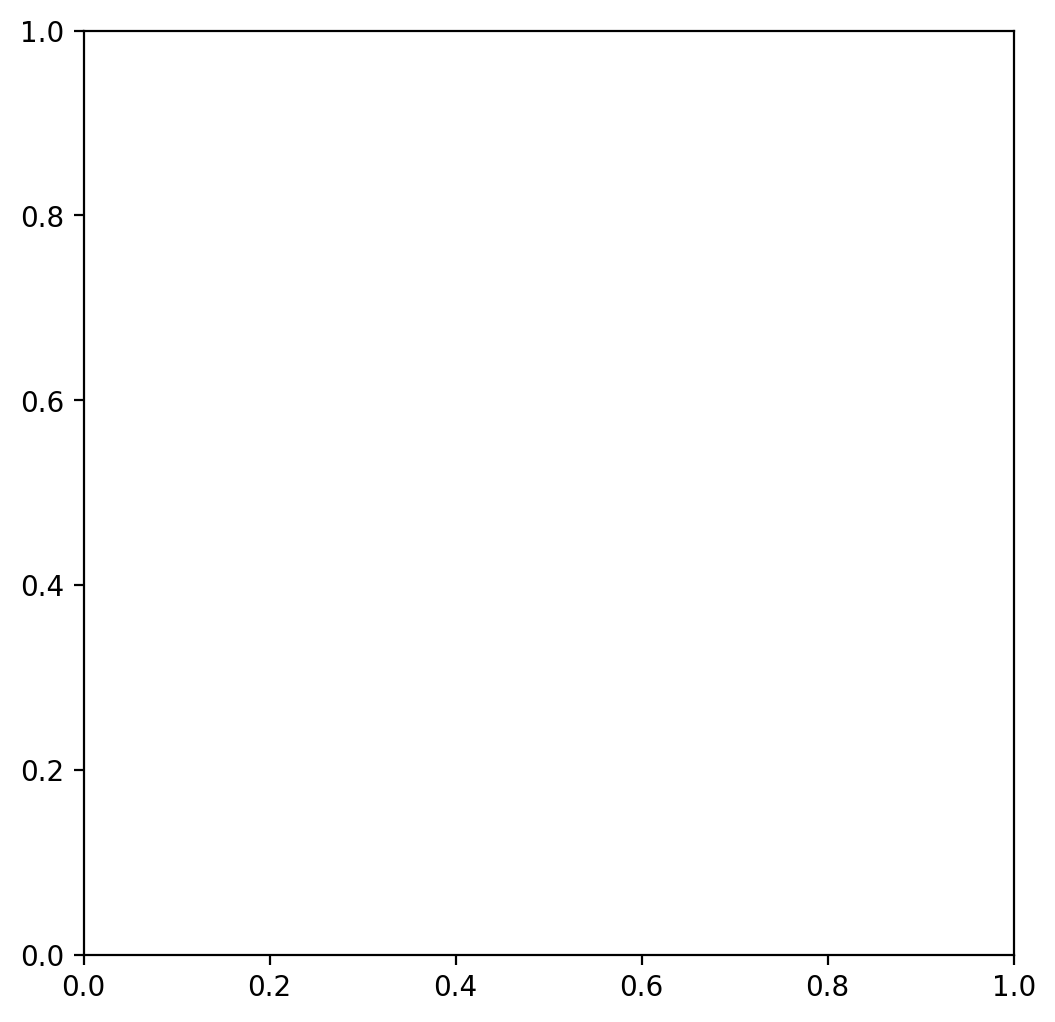

In [11]:
# plot contribution function depending on pressure level and (central) wavelength
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

plt.imshow(np.log10(contribution_data[:,4:].T), 
            aspect='auto', 
            origin='lower', 
            extent=[np.log10(contribution_data[0,2]), np.log10(contribution_data[-1,2]+contribution_data[-1,3]), 
                    np.log10(run.pressures_bar.max()), np.log10(run.pressures_bar.min())],
            cmap='viridis',
            vmin=5
          )

#plt.xlim(10, None)
#plt.xscale('log')
#plt.yscale('log')

plt.colorbar(label='Contribution Function')
plt.xlabel('Wavelength [um]')
plt.ylabel('Log10 Pressure [bar]')
plt.title(f'Contribution Function for {run.run_name.replace("_", ", ")}')

In [12]:
# emission spectrum (_TOA_flux_eclipse.dat)
# Header: bin     cent_lambda[um]   low_int_lambda[um]   delta_lambda[um]   F_down_at_TOA   F_up_at_TOA     planet/star flux ratio

emission_file = output_folder + run_name + f"/{run_name}_TOA_flux_eclipse.dat"
emission_data = np.loadtxt(emission_file, skiprows=3)

c = 2.998e10  # speed of light in cm/s

r_earth = 6.371e8  # in cm
r_planet = 1.0 * r_earth

pc = 3.086e18  # 1 parsec in cm
distance = 3 * pc

# convert
f_up = emission_data[:, 5] * (r_planet / distance)**2  # erg/s/cm^3 at distance d

f_up = f_up * ((emission_data[:, 1] * 1e-4)**2 / c)  # erg/s/cm^2/Hz

f_up = f_up * 1e23  # Jy
f_up = f_up * 1e6   # uJy

FileNotFoundError: ../output/N2dom_fast/Earth_Tint=150K_Psurf=100bar_aH=1.0_aC=0.5_aO=0.01_aN=1.0/Earth_Tint=150K_Psurf=100bar_aH=1.0_aC=0.5_aO=0.01_aN=1.0_TOA_flux_eclipse.dat not found.

NameError: name 'emission_data' is not defined

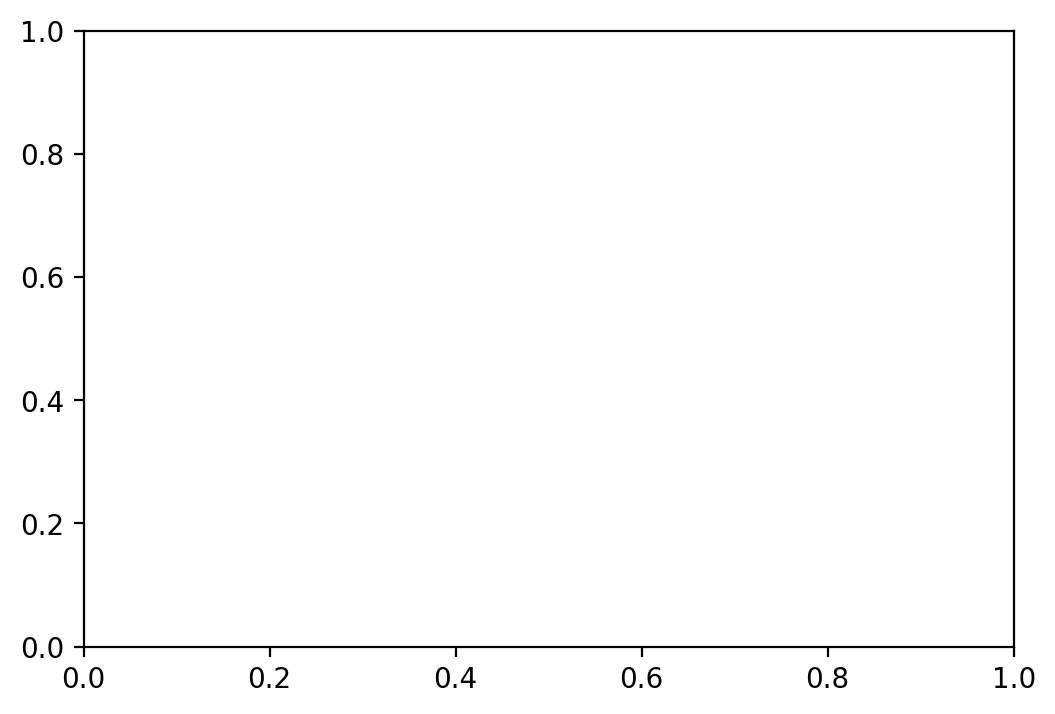

In [13]:
# plot F_up_at_TOA vs (central) wavelength
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(emission_data[:,1], f_up)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e-3, 1e4)

ax.set_xlabel('Wavelength [um]')
ax.set_ylabel('F_up_at_TOA [uJy]')
ax.set_title(f'Emission Spectrum for {run.run_name.replace("_", ", ")}')
plt.show()

In [7]:
print(0.1/1.1)

0.09090909090909091
